In [286]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t
import yfinance as yf
from scipy.optimize import minimize_scalar


In [287]:
#chargement des donnés de l'actif S&P500

data = yf.download(
    "^GSPC",
    start="2018-01-01",
    auto_adjust=True
)

prices = data["Close"].squeeze()

[*********************100%***********************]  1 of 1 completed


In [288]:
prices

,^GSPC
Date,
2018-01-02,2695.810059
2018-01-03,2713.060059
2018-01-04,2723.989990
2018-01-05,2743.149902
2018-01-08,2747.709961
...,...
2026-09-03,7747.709961
2026-09-04,7718.600098
2026-09-08,7673.520020


#Calcul des rendements

Le rendement entre les dates $t-1$ et $t$ est donné par: $$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [289]:
returns = np.log(prices / prices.shift(1)).dropna()

In [290]:
returns

,^GSPC
Date,
2018-01-03,0.006378
2018-01-04,0.004021
2018-01-05,0.007009
2018-01-08,0.001661
2018-01-09,0.001302
...,...
2026-09-03,0.010524
2026-09-04,-0.003764
2026-09-08,-0.005858


Analyse descriptive

In [291]:
print(returns.describe())

count    2183.000000
mean        0.000474
std         0.012113
min        -0.127652
25%        -0.004391
50%         0.000881
75%         0.006448
max         0.090895
Name: ^GSPC, dtype: float64


In [292]:
def estimate_ewma_lambda(returns):
    # Nettoyage
    r = np.asarray(returns.dropna(), dtype=float)

    # Centrage des rendements
    r = r - np.mean(r)

    # Variance initiale
    initial_variance = np.var(r, ddof=1)

    def negative_log_likelihood(lam):

        variances = np.empty(len(r))
        variances[0] = initial_variance
        for t in range(1, len(r)):
            variances[t] = (lam * variances[t - 1] + (1 - lam) * r[t - 1]**2)
        variances = np.maximum(variances, 1e-12)

        # Log-vraisemblance normale
        log_likelihood = -0.5 * np.sum(np.log(2 * np.pi)+ np.log(variances) + r**2 / variances)

        return -log_likelihood

    # Optimisation de lambda
    result = minimize_scalar(negative_log_likelihood,bounds=(0.80, 0.999), method="bounded")

    return result.x


In [293]:
lamba1=estimate_ewma_lambda(returns)
lamba1

np.float64(0.9152400601910425)

#Calcule la volatilité EWMA.

In [294]:
def ewma_volatility(returns, lamb=lamba1):

    returns = pd.Series(returns).dropna()

    variances= np.zeros(len(returns))

    # Initialisation avec la variance historique
    variances[0] = returns.iloc[:10].var()

    for i in range(1, len(returns)):
        variances[i] = ( lamb * variances[i - 1] + (1 - lamb) * returns.iloc[i - 1] ** 2)

    volatility = np.sqrt(variances)

    return pd.Series(volatility,index=returns.index,name="EWMA_Volatility")

In [295]:
ewma_vol = ewma_volatility( returns, lamba1 )
ewma_vol

,EWMA_Volatility
Date,
2018-01-03,0.004157
2018-01-04,0.004389
2018-01-05,0.004359
2018-01-08,0.004643
2018-01-09,0.004468
...,...
2026-09-03,0.005990
2026-09-04,0.006498
2026-09-08,0.006313


#Predire la volatilité au jour suivant

In [296]:
dernier_sigma = ewma_vol.iloc[-1]
dernier_return = returns.iloc[-1]
lamb=lamba1

variance_future = (lamb * dernier_sigma**2 + (1 - lamb) * dernier_return ** 2)
volatility_future = np.sqrt(variance_future)
print("Volatilité EWMA prévue :", volatility_future)

Volatilité EWMA prévue : 0.006142775609110594


#Calcul de ewma_VaR à un jour

In [297]:
def ewma_var(returns,portfolio_value,confidence=0.99,lamb=lamba1,include_mean=True):

    returns = pd.Series(returns).dropna()
    ewma_vol = ewma_volatility(returns,lamb)
    sigma_t = ewma_vol.iloc[-1] #dernier volatilité
    r_t = returns.iloc[-1]      # Dernier rendement observé

    sigma_future = np.sqrt(lamb * sigma_t ** 2 + (1 - lamb) * r_t ** 2)

    # Moyenne des rendements
    if include_mean:
        mu = returns.mean()
    else:
        mu = 0.0

    # Quantile de la loi normale
    z = norm.ppf(confidence)


    VaR = portfolio_value * (z * sigma_future - mu)

    return {
        "model": "EWMA-Normal",
        "confidence": confidence,
        "lambda": lamb,
        "mean_return": mu,
        "volatility_future": sigma_future,
        "ewma_VaR": VaR
    }

In [298]:
result = ewma_var(
    returns,
    portfolio_value=1_000_000,
    confidence=0.99,
    lamb=lamba1
)

result

{'model': 'EWMA-Normal',
 'confidence': 0.99,
 'lambda': np.float64(0.9152400601910425),
 'mean_return': np.float64(0.00047428043812107516),
 'volatility_future': np.float64(0.006142775609110594),
 'ewma_VaR': np.float64(13815.952540843286)}

Modèle GARCH(1,1)

In [299]:
%pip install arch

In [300]:
from arch import arch_model

In [301]:
returns_pct = returns * 100

model = arch_model(returns_pct,mean="Constant",vol="GARCH",p=1,q=1,dist="normal")

result = model.fit(disp="off")

print(result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3005.86
Distribution:                  Normal   AIC:                           6019.72
Method:            Maximum Likelihood   BIC:                           6042.48
                                        No. Observations:                 2183
Date:                Thu, Sep 10 2026   Df Residuals:                     2182
Time:                        19:57:11   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0845  1.778e-02      4.754  1.990e-06 [4.969e-0

In [302]:
params = result.params

In [303]:
mu = params["mu"]
omega = params["omega"]
alpha = params["alpha[1]"]
beta = params["beta[1]"]

print("mu =", mu)
print("omega =", omega)
print("alpha =", alpha)
print("beta =", beta)
print("Persistence =", alpha + beta)

mu = 0.08453557494099775
omega = 0.05233371462458169
alpha = 0.16441101719953327
beta = 0.7956576288696909
Persistence = 0.9600686460692243


La quantité "alpha + beta" est particulièrement importante. Une valeur proche de 1 indique une forte persistance de la volatilité.

In [304]:

forecast = result.forecast(horizon=1) #Prévision à J+1
forecast_variance = forecast.variance.iloc[-1, 0] #Récupération de la variance prévue
forecast_vol_pct = np.sqrt(forecast_variance) # Variance → volatilité
forecast_vol = forecast_vol_pct / 100 # Pourcentage → décimal

In [305]:
forecast.variance.iloc[-1,0]

np.float64(0.5679062138885499)

In [306]:
def garch_var_normal(returns, portfolio_value, confidence=0.99):

    returns = pd.Series(returns).dropna()
    returns_pct = returns * 100

    # Définition du modèle GARCH(1,1)
    model = arch_model(returns_pct, mean="Constant", vol="GARCH", p=1, q=1, dist="normal" )

    # Estimation du modèle
    fitted = model.fit(disp="off")

    # Prévision à J+1
    forecast = fitted.forecast(horizon=1 )

    variance_pct = forecast.variance.iloc[-1, 0]

    sigma_pct = np.sqrt(variance_pct)

    sigma = sigma_pct / 100

    # Moyenne estimée convertie en décimal
    mu = fitted.params["mu"] / 100

    # Quantile de la loi normale
    z = norm.ppf(confidence)

    # VaR en rendement
    var_return = (z * sigma - mu)

    # VaR en valeur monétaire
    var_money = (portfolio_value * var_return)

    return {
        "model": "GARCH(1,1)-Normal",
        "confidence": confidence,
        "mean_forecast": mu,
        "forecast_volatility": sigma,
        "omega": fitted.params["omega"],
        "alpha": fitted.params["alpha[1]"],
        "beta": fitted.params["beta[1]"],
        "persistence": (fitted.params["alpha[1]"] + fitted.params["beta[1]"]),
        "VaR_return": var_return,
        "VaR_money": var_money,
        "fitted_model": fitted
    }

In [307]:
result_garch = garch_var_normal(returns, portfolio_value=1_000_000, confidence=0.99)

print("VaR GARCH 99 % :", result_garch["VaR_money"])

VaR GARCH 99 % : 16685.89770350832


In [329]:
def parametric_var(returns, portfolio_value, confidence=0.99, method="garch_normal", lamb=lamba1):

    method = method.lower()

    if method == "ewma":

        return ewma_var(returns=returns,portfolio_value=portfolio_value,confidence=confidence,lamb=lamb)

    elif method == "garch_normal":

        return garch_var_normal(returns=returns,portfolio_value=portfolio_value, confidence=confidence )

    else:

        raise ValueError("Méthode inconnue. " "Utiliser 'ewma' " "ou 'garch_normal'.")

In [309]:
ewma_result = parametric_var(returns,portfolio_value=10_000_000,confidence=0.99,method="ewma")

print("VaR EWMA :",ewma_result["ewma_VaR"])

VaR EWMA : 138159.52540843285


In [310]:
garch_normal_result = parametric_var(returns,portfolio_value=10_000_000,confidence=0.99,method="garch_normal")

print( "VaR GARCH-Normal :",garch_normal_result["VaR_money"])

VaR GARCH-Normal : 166858.9770350832


In [311]:
comparison = pd.DataFrame({
    "Modèle": ["EWMA", "GARCH-Normal"],
    "Volatilité prévue": [ewma_result["volatility_future"],garch_normal_result["forecast_volatility"]],

    "VaR (€)": [ewma_result["ewma_VaR"], garch_normal_result["VaR_money"]]})

print(comparison)

         Modèle  Volatilité prévue        VaR (€)
0          EWMA           0.006143  138159.525408
1  GARCH-Normal           0.007536  166858.977035


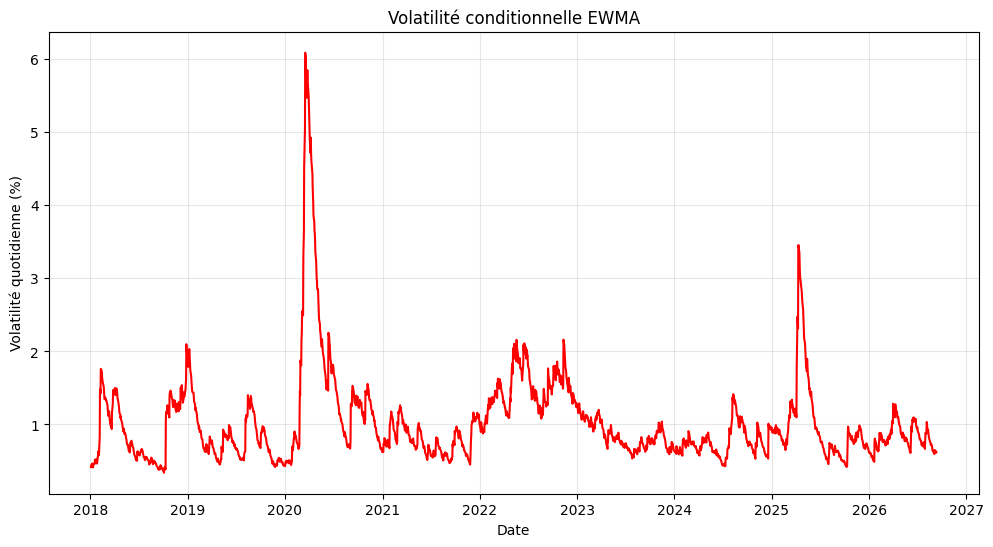

In [312]:
# Graphique de volatilité EWMA
plt.figure(figsize=(12, 6))

plt.plot(ewma_vol.index,ewma_vol * 100,color="red")

plt.title("Volatilité conditionnelle EWMA")
plt.xlabel("Date")
plt.ylabel("Volatilité quotidienne (%)")
plt.grid(alpha=0.3)
plt.show()

Le graphique présente l'évolution de la **volatilité conditionnelle quotidienne estimée par le modèle EWMA (Exponentially Weighted Moving Average)** sur la période 2018–2026.

La volatilité varie fortement au cours du temps et réagit rapidement aux périodes de turbulence des marchés. Le pic le plus important apparaît en **2020**, avec une volatilité dépassant **6 %**, tandis que d'autres épisodes de hausse du risque sont observés notamment en **2022** et en **2025**. Entre ces périodes de stress, la volatilité revient progressivement vers des niveaux plus faibles.


Le modèle EWMA accorde davantage de poids aux observations récentes et réduit progressivement l'influence des observations plus anciennes.

Le graphique met également en évidence le phénomène de **volatility clustering**: les épisodes de forte volatilité ont tendance à se concentrer dans le temps. L'approche EWMA permet ainsi de construire une mesure **dynamique du risque**, qui s'adapte rapidement aux nouvelles conditions de marché.

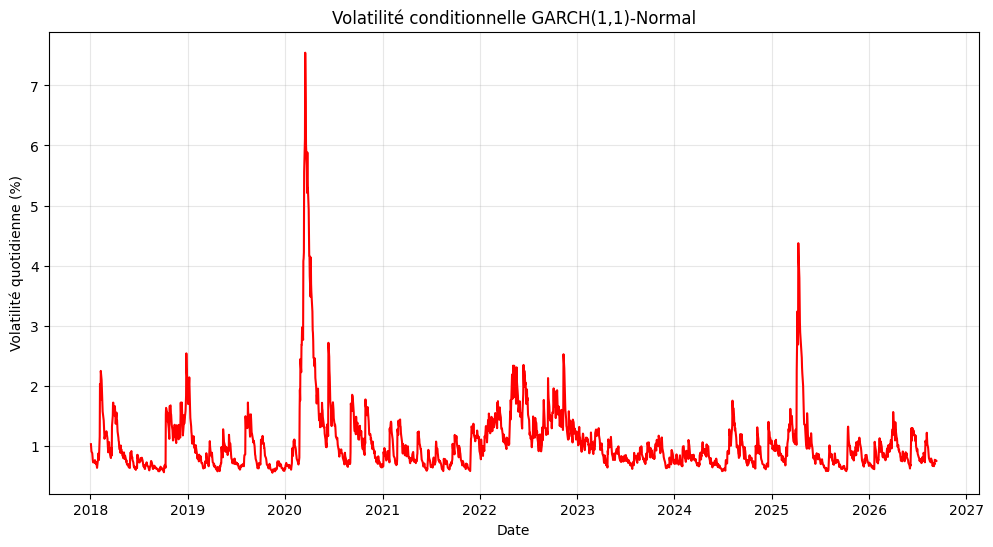

In [313]:
# Graphique de volatilité GARCH-Normal

fitted = garch_normal_result["fitted_model"]
garch_vol = fitted.conditional_volatility
plt.figure(figsize=(12, 6))
plt.plot(garch_vol.index, garch_vol,color="red")
plt.title("Volatilité conditionnelle GARCH(1,1)-Normal")
plt.xlabel("Date")
plt.ylabel("Volatilité quotidienne (%)")
plt.grid(alpha=0.3)
plt.show()

### Analyse de la volatilité conditionnelle GARCH(1,1)

Le graphique présente l'évolution de la **volatilité conditionnelle quotidienne** estimée à l'aide d'un modèle **GARCH(1,1) avec innovations normales** sur la période 2018–2026.

On observe que la volatilité n'est pas constante dans le temps. Elle alterne entre des périodes relativement calmes, où elle se situe généralement autour de **1 %**, et des périodes de fortes turbulences caractérisées par des pics importants. L'épisode le plus marqué apparaît en **2020**, avec une volatilité dépassant **7 %**, traduisant une forte augmentation de l'incertitude sur les marchés. D'autres épisodes de tension sont également visibles en **2022** et en **2025**.



Cette dynamique met clairement en évidence le phénomène de **volatility clustering** : les périodes de forte volatilité ont tendance à être suivies par d’autres périodes de forte volatilité, tandis que les périodes calmes tendent également à persister.

Le modèle GARCH permet ainsi de prendre en compte le caractère **dynamique et persistant du risque de marché**, contrairement à une approche supposant une volatilité constante.

In [324]:
def ewma_var_series(returns,portfolio_value,confidence=0.99,lamb=lamba1):
    """
    Calcule une série historique de VaR EWMA.
    """

    # Calcul de la volatilité EWMA
    vol = ewma_volatility(returns,lamb)

    # Quantile de la loi normale
    z = norm.ppf(confidence)
    #VaR en rendement
    var_return = z * vol

    # VaR en valeur monétaire
    var_money = portfolio_value* z * vol
    # Création du DataFrame
    output = pd.DataFrame(
        {
            "Return": returns,
            "Volatility": vol,
            "var": var_return,
            "VaR_Money": var_money
        }
    )

    return output

In [325]:
ewma_history = ewma_var_series(returns,portfolio_value=1_000_000, confidence=0.99)


In [316]:
ewma_history.head()

,Return,Volatility,var,VaR_Money
Date,,,,
2018-01-03,0.006378,0.004157,0.009670,9670.361086
2018-01-04,0.004021,0.004389,0.010210,10210.382167
2018-01-05,0.007009,0.004359,0.010141,10140.536871
2018-01-08,0.001661,0.004643,0.010800,10800.473854
2018-01-09,0.001302,0.004468,0.010394,10393.674185


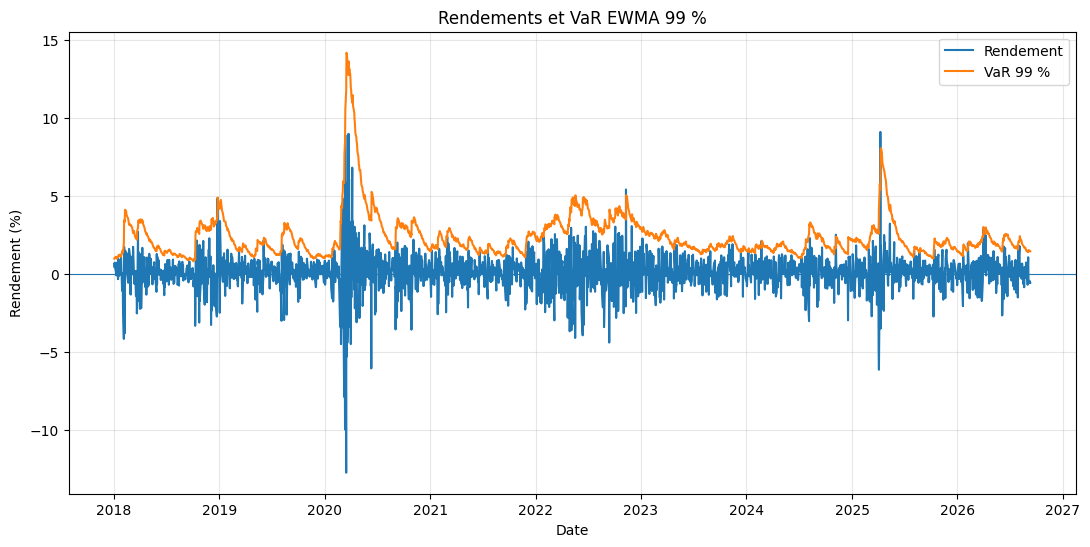

In [340]:
plt.figure(figsize=(13, 6))

plt.plot(ewma_history.index,ewma_history["Return"] * 100, label="Rendement")

plt.plot(ewma_history.index, ewma_history["var"] * 100,label="VaR 99 %")

plt.axhline(0,linewidth=0.8)

plt.title("Rendements et VaR EWMA 99 %")
plt.ylabel("Rendement (%)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Le graphique dessus met en évidence l'évolution des **rendements journaliers du portefeuille** ainsi que de la **VaR dynamique à 99 %** sur la période 2018–2026.

On observe que la VaR s'adapte aux changements de volatilité du marché: elle reste relativement proche de zéro pendant les périodes calmes, mais devient nettement plus grande lors des épisodes de forte turbulence. Ce phénomène est particulièrement visible en **2020**, où l'explosion de la volatilité entraîne une forte augmentation du risque estimé, ainsi qu'en **2022 et 2025**, où de nouveaux épisodes de tension apparaissent.


In [334]:
# Actifs
tickers = ["AAPL","MSFT","GOOGL","AMZN"]

data_assets = yf.download(
    tickers,
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True
)
prices_assets = data_assets["Close"]
prices_assets = prices_assets.dropna()



[*********************100%***********************]  4 of 4 completed


In [335]:
prices_assets.head()


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2018-01-02,40.232372,59.450500,53.154690,78.552025
2018-01-03,40.225372,60.209999,54.061565,78.917603
2018-01-04,40.412212,60.479500,54.271568,79.612183
2018-01-05,40.872330,61.457001,54.991222,80.599243
2018-01-08,40.720516,62.343498,55.185371,80.681480


In [336]:

#Calcul des rendements logarithmiques
asset_returns = np.log(prices_assets / prices_assets.shift(1)).dropna()
asset_returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2018-01-03,-0.000174,0.012694,0.016917,0.004643
2018-01-04,0.004634,0.004466,0.003877,0.008763
2018-01-05,0.011321,0.016033,0.013173,0.012322
2018-01-08,-0.003721,0.014322,0.003524,0.001020
2018-01-09,-0.000115,0.004665,-0.001275,-0.000680


In [337]:
 #Fonction de calcul du rendement du portefeuille
def portfolio_returns(asset_returns,weights):
    weights = np.asarray(weights)

    if len(weights) != asset_returns.shape[1]:
        raise ValueError("Le nombre de poids doit " "correspondre au nombre d'actifs.")

    return asset_returns.dot(weights)
weights = np.array([ 0.40,0.30,0.20,0.10])



In [338]:
# Calcul des rendements du portefeuille
port_returns = portfolio_returns(asset_returns,weights)
port_returns.head()

,0
Date,
2018-01-03,0.007586
2018-01-04,0.004845
2018-01-05,0.013205
2018-01-08,0.003615
2018-01-09,0.001030


In [339]:
#Calcul de la VaR GARCH-Normal
result = garch_var_normal(port_returns,portfolio_value=5_000_000,confidence=0.99)
print("=" * 30)
print(" VaR-MODÈLE GARCH(1,1)-NORMAL")
print("=" * 30)

print(f"\nModèle                : {result['model']}")
print(f"Niveau de confiance   : {result['confidence']:.0%}")

print("\n--- Prévisions ---")
print(f"Rendement moyen prévu : {result['mean_forecast']:.4%}")
print(f"Volatilité prévue      : {result['forecast_volatility']:.4%}")

print("\n--- Paramètres GARCH ---")
print(f"Omega (ω)              : {result['omega']:.6f}")
print(f"Alpha (α)              : {result['alpha']:.6f}")
print(f"Beta  (β)              : {result['beta']:.6f}")
print(f"Persistance (α + β)    : {result['persistence']:.6f}")

print("\n--- Value at Risk ---")
print(f"VaR en rendement       : {result['VaR_return']:.4%}")
print(f"VaR monétaire          : {result['VaR_money']:,.2f} €")

print("\n" + "=" * 55)

 VaR-MODÈLE GARCH(1,1)-NORMAL

Modèle                : GARCH(1,1)-Normal
Niveau de confiance   : 99%

--- Prévisions ---
Rendement moyen prévu : 0.1366%
Volatilité prévue      : 0.9945%

--- Paramètres GARCH ---
Omega (ω)              : 0.096611
Alpha (α)              : 0.113750
Beta  (β)              : 0.852776
Persistance (α + β)    : 0.966527

--- Value at Risk ---
VaR en rendement       : 2.1769%
VaR monétaire          : 108,847.28 €

